In [ ]:
import shutil

import duckdb
from networks.cnn_deep import CNNModel
import pandas as pd

con = duckdb.connect('../capillary.db')
df = con.execute(""" 
                 SELECT row_id, value,fractions, boundaries,albumin,antitrypsin,orosomukoid,haptoglobin,crp,igg,iga,igm, label, set, interpretation
                 FROM protein_data
                 WHERE observation_nr = 1
                
                 """).df()
con.close()


train_rows = df[df['set'] == 'train']
val_rows   = df[df['set'] == 'val']
test_rows  = df[df['set'] == 'test']

extra_val = train_rows.sample(frac=0.1, random_state=42)
train_rows = train_rows.drop(extra_val.index)
val_rows = pd.concat([val_rows, extra_val], ignore_index=True)

drop_indices = train_rows[train_rows['label'] == 0].sample(frac=0.7).index

train_rows = train_rows.drop(drop_indices)

train_rows = train_rows[train_rows['label'].isin([0,1])]
val_rows = val_rows[val_rows['label'].isin([0,1])]
test_rows = test_rows[test_rows['label'].isin([0,1])]

print(f"Antal utan m-komponent i träningsdatan: {len(train_rows[train_rows['label'] == 0])}")
print(f"Antal med m-komponent i träningsdatan: {len(train_rows[train_rows['label'] == 1])}")

print(f"-----\nAntal utan m-komponent i valideringsdatan: {len(val_rows[val_rows['label'] == 0])}")
print(f"Antal med m-komponent i valideringsdatan: {len(val_rows[val_rows['label'] == 1])}")

CNN = CNNModel()
cnn_train_dl, cnn_val_dl, _ = CNN.build_dataloaders(train_rows, val_rows, val_rows)




Antal utan m-komponent i träningsdatan: 24521
Antal med m-komponent i träningsdatan: 28643
-----
Antal utan m-komponent i valideringsdatan: 13809
Antal med m-komponent i valideringsdatan: 5013
Total parameters: 320,194


In [ ]:
results = []

best_auc = -1
best_run = None

for run in range(10):
    print(f"Körning {run+1}/10")

    CNN = CNNModel()


    auc = CNN.retrain(
        train_dl=cnn_train_dl,
        val_dl=cnn_val_dl,
        patience=10,
        model_path=f"../models/temp_m_component_{run}.pth"
    )

    results.append({
        "run": run + 1,
        "val_auc": auc
    })

    if auc > best_auc:
        best_auc = auc
        best_run = run + 1
        print(CNN.model_path)
        shutil.copy(
            f"../models/temp_m_component_{run}.pth",
            CNN.model_path
        )

result_df = pd.DataFrame(results)
result_df.to_csv("../results/m_component_runs.csv", index=False)

print(result_df)
print(f"Bästa körning: {best_run}")
print(f"Bästa val AUC: {best_auc:.4f}")

              precision    recall  f1-score   support

     Negativ       0.99      0.89      0.94     10824
     Positiv       0.72      0.96      0.82      3276

    accuracy                           0.91     14100
   macro avg       0.85      0.92      0.88     14100
weighted avg       0.93      0.91      0.91     14100

[[9626 1198]
 [ 136 3140]]


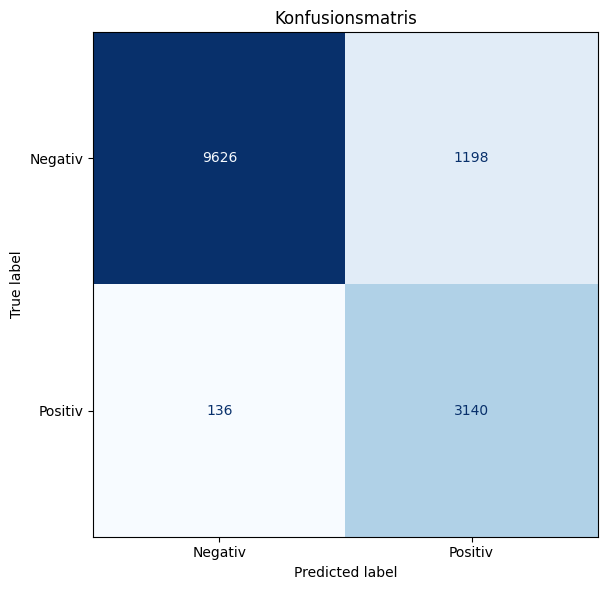

AUC: 0.9812129351001302
Accuracy:  90.54%
FN-rate:   4.15%  (farliga missade fall)
FP-rate:   11.07%  (onödiga larm)
Sensitivitet:   95.85%  (Sannolikhet att upptäcka ett positivt fall)
Specificitet:   88.93%  (Sannolikhet att korrekt klassificera ett negativt fall negativt)
AUC: 0.9812


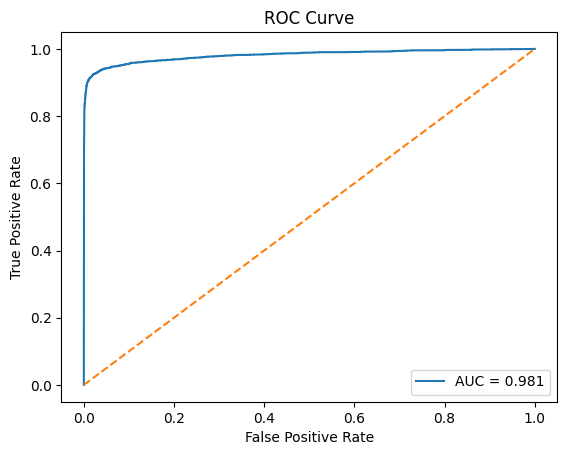

In [10]:
result = CNN.predict(test_rows)
df = CNN.evaluate(result,threshold=0.01)

